# SETUP

In [ ]:
# --- SETUP ---
!pip install -q langchain langgraph langsmith openai duckduckgo-search wikipedia

import os
from getpass import getpass
import math

# LangSmith & OpenAI Keys Setup

In [ ]:
os.environ["LANGCHAIN_API_KEY"] = getpass("🔑 Enter your LangSmith API Key: ")
os.environ["LANGCHAIN_PROJECT"] = "Effective AI Agents Showcase"
os.environ["OPENAI_API_KEY"] = getpass("🔑 Enter your OpenAI API Key: ")

🔑 Enter your LangSmith API Key: ··········
🔑 Enter your OpenAI API Key: ··········


In [ ]:
!pip install langchain-community

# Imports

# Tools Setup

In [ ]:
# --- Imports ---
from langchain.agents import initialize_agent, Tool
from langchain.agents.agent_types import AgentType
from langchain.agents.agent import AgentExecutor
from langchain.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain.llms import OpenAI
from langgraph.graph import StateGraph
from langchain_community.utilities.wikipedia import WikipediaAPIWrapper

# --- Tools Setup ---
duckduckgo_tool = Tool(
    name="DuckDuckGoSearch",
    func=DuckDuckGoSearchRun().run,
    description="Search using DuckDuckGo. Useful for real-time info."
)

wiki_wrapper = WikipediaAPIWrapper(lang="en")
wikipedia_tool = Tool(
    name="Wikipedia",
    func=WikipediaQueryRun(api_wrapper=wiki_wrapper).run,
    description="Search Wikipedia articles for factual knowledge."
)

def safe_calculator(expr):
    try:
        expr_clean = expr.replace(",", "")  # remove commas for large numbers
        return str(eval(expr_clean, {"__builtins__": {}}, {"sqrt": math.sqrt}))
    except Exception as e:
        return f"Calculator error: {e}"

calculator_tool = Tool(
    name="Calculator",
    func=safe_calculator,
    description="Useful for mathematical calculations using sqrt, +, -, *, /."
)

all_tools = [duckduckgo_tool, wikipedia_tool, calculator_tool]

llm = OpenAI(temperature=0, max_tokens=512)  # prevent context overflow

# 1. ReAct Pattern (LangGraph)

In [ ]:
# ----------------------------
# 1. ReAct Pattern (LangGraph)
# ----------------------------
print("\n🔧 ReAct Agent with LangGraph")
react_agent = initialize_agent(
    tools=all_tools,
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

query = "Using the latest Wikipedia result, calculate France's current population (68,606,000) divided by sqrt(49). Only use calculator for math."
response = react_agent.run(query)
print(response)


🔧 ReAct Agent with LangGraph


> Entering new AgentExecutor chain...
 I should use Wikipedia to find the latest information on France's population and then use the calculator to perform the calculation.
Action: Wikipedia
Action Input: France population
Observation: Page: Demographics of France
Summary: The demography of France is monitored by the Institut national d'études démographiques (INED) and the Institut national de la statistique et des études économiques (INSEE). As of 1 January 2025, 66,352,000 people lived in Metropolitan France, while 2,254,000 lived in overseas France, for a total of 68,606,000 inhabitants in the French Republic. In January 2022, the population of France officially reached the 68,000,000 mark. The population of France is growing by 1,000,000 people every three years- an average annual increase of 340,000 people, or +0.6%.
France was historically Europe's most populous country. During the Middle Ages, more than one-quarter of Europe's total population was 

In [ ]:
# LangSmith Trace: ReAct Agent
# ![ReAct LangSmith Trace](https://via.placeholder.com/800x400?text=ReAct+Trace+Screenshot)


# 2. Plan-and-Execute Pattern

In [ ]:
# ----------------------------
# 2. Plan-and-Execute Pattern
# ----------------------------
print("\n📋 Plan-and-Execute Agent")

plan_agent = initialize_agent(
    tools=all_tools,
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,
    handle_parsing_errors=True
)

response = plan_agent.run("Compare the GDP of Germany and Japan and give a short analysis.")
print(response)


📋 Plan-and-Execute Agent


> Entering new AgentExecutor chain...
 I should use Wikipedia to search for information on the GDP of Germany and Japan.
Action: Wikipedia
Action Input: "GDP of Germany" and "GDP of Japan"
Observation: Page: List of countries by largest historical GDP
Summary: This list of countries by largest historical GDP shows how the membership and rankings of the world's ten largest economies as measured by their gross domestic product has changed. While the United States has consistently had the world's largest economy for some time, in the last fifty years the world has seen both rises and falls in relative terms of the economies of other countries.



Page: World economy
Summary: The world economy or global economy is the economy of all humans in the world, referring to the global economic system, which includes all economic activities conducted both within and between nations, including production, consumption, economic management, work in general, financial transa

In [ ]:
#### 📋 LangSmith Trace for Plan-and-Execute Agent

![Plan-and-Execute LangSmith Trace](https://via.placeholder.com/800x400?text=Plan+Execute+Trace)


/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `[Plan-and-Execute LangSmith Trace](https://via.placeholder.com/800x400?text=Plan+Execute+Trace)'


# 3. Tool-Use LangGraph Agent

In [ ]:
# ----------------------------
# 3. Tool-Use LangGraph Agent
# ----------------------------
print("\n🛠 Tool-Use via LangGraph")

def agent_node(state):
    question = state["question"]
    output = react_agent.run(question)
    return {"result": output}

builder = StateGraph(dict)
builder.add_node("agent", agent_node)
builder.set_entry_point("agent")
workflow = builder.compile()

workflow.invoke({"question": "Who won the FIFA World Cup in 2018 and what is the capital of that country?"})


🛠 Tool-Use via LangGraph


> Entering new AgentExecutor chain...
 I should search for this information on Wikipedia.
Action: Wikipedia
Action Input: "2018 FIFA World Cup"
Observation: Page: 2018 FIFA World Cup
Summary: The 2018 FIFA World Cup was the 21st FIFA World Cup, the quadrennial world championship for national football teams organized by FIFA. It took place in Russia from 14 June to 15 July 2018, after the country was awarded the hosting rights in late 2010. It was the eleventh time the championships had been held in Europe and the first time they were held in Eastern Europe, also featuring one or two venues, depending on definition, located across the boundary with Asia. At an estimated cost of over $14.2 billion, it was the most expensive World Cup ever held until it was surpassed by the 2022 World Cup in Qatar.
The tournament phase involved 32 teams, of which 31 came through qualifying competitions, while the host nation Russia qualified automatically. Of the 32, 20 had als

/usr/local/lib/python3.11/dist-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /usr/local/lib/python3.11/dist-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')



Observation: Page: France
Summary: France, officially the French Republic, is a country located primarily in Western Europe. Its overseas regions and territories include French Guiana in South America, Saint Pierre and Miquelon in the North Atlantic, the French West Indies, and many islands in Oceania and the Indian Ocean, giving it one of the largest discontiguous exclusive economic zones in the world. Metropolitan France shares borders with Belgium and Luxembourg to the north, Germany to the northeast, Switzerland to the east, Italy and Monaco to the southeast, Andorra and Spain to the south, and a maritime border with the United Kingdom to the northwest. Its metropolitan area extends from the Rhine to the Atlantic Ocean and from the Mediterranean Sea to the English Channel and the North Sea. Its eighteen integral regions—five of which are overseas—span a combined area of 632,702 km2 (244,288 sq mi) and have an estimated total population of over 68.6 million as of January 2025. Fran

{'result': 'The 2018 FIFA World Cup was won by France and the capital of France is Paris.'}

In [ ]:
#### 🛠 LangSmith Trace for Tool-Use Graph

![Tool-Use Trace](https://via.placeholder.com/800x400?text=Tool+Use+LangGraph+Trace)


/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `[Tool-Use Trace](https://via.placeholder.com/800x400?text=Tool+Use+LangGraph+Trace)'


# 4. Memory-Augmented Agent

In [ ]:
# ----------------------------
# 4. Memory-Augmented Agent
# ----------------------------
print("\n🧠 Memory-Augmented Agent")

from langchain.memory import ConversationBufferMemory

memory = ConversationBufferMemory(memory_key="chat_history")
memory_agent = initialize_agent(
    tools=all_tools,
    llm=llm,
    agent=AgentType.CONVERSATIONAL_REACT_DESCRIPTION,
    verbose=True,
    memory=memory
)

print(memory_agent.run("Who is Elon Musk?"))
print(memory_agent.run("What company did he found after PayPal?"))
print(memory_agent.run("Remind me what we discussed so far."))


🧠 Memory-Augmented Agent


> Entering new AgentExecutor chain...


<ipython-input-31-ae0ee5e1ea84>:8: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(memory_key="chat_history")



Thought: Do I need to use a tool? Yes
Action: Wikipedia
Action Input: Elon Musk
Observation: Page: Elon Musk
Summary: Elon Reeve Musk ( EE-lon; born June 28, 1971) is a businessman known for his leadership of Tesla, SpaceX, and X (formerly Twitter). Since 2025, he has been a senior advisor to United States President Donald Trump and the de facto head of the Department of Government Efficiency (DOGE). Musk is the wealthiest person in the world; as of March 2025, Forbes estimates his net worth to be US$345 billion. He was named Time magazine's Person of the Year in 2021.
Born to a wealthy family in Pretoria, South Africa, Musk emigrated in 1989 to Canada. He graduated from the University of Pennsylvania in the U.S. before moving to California to pursue business ventures. In 1995, Musk co-founded the software company Zip2. Following its sale in 1999, he co-founded X.com, an online payment company that later merged to form PayPal, which was acquired by eBay in 2002. That year, Musk also b

In [ ]:
#### 🧠 LangSmith Trace for Memory-Augmented Agent

![Memory Agent Trace](https://via.placeholder.com/800x400?text=Memory+Agent+LangSmith+Trace)


/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `[Memory Agent Trace](https://via.placeholder.com/800x400?text=Memory+Agent+LangSmith+Trace)'


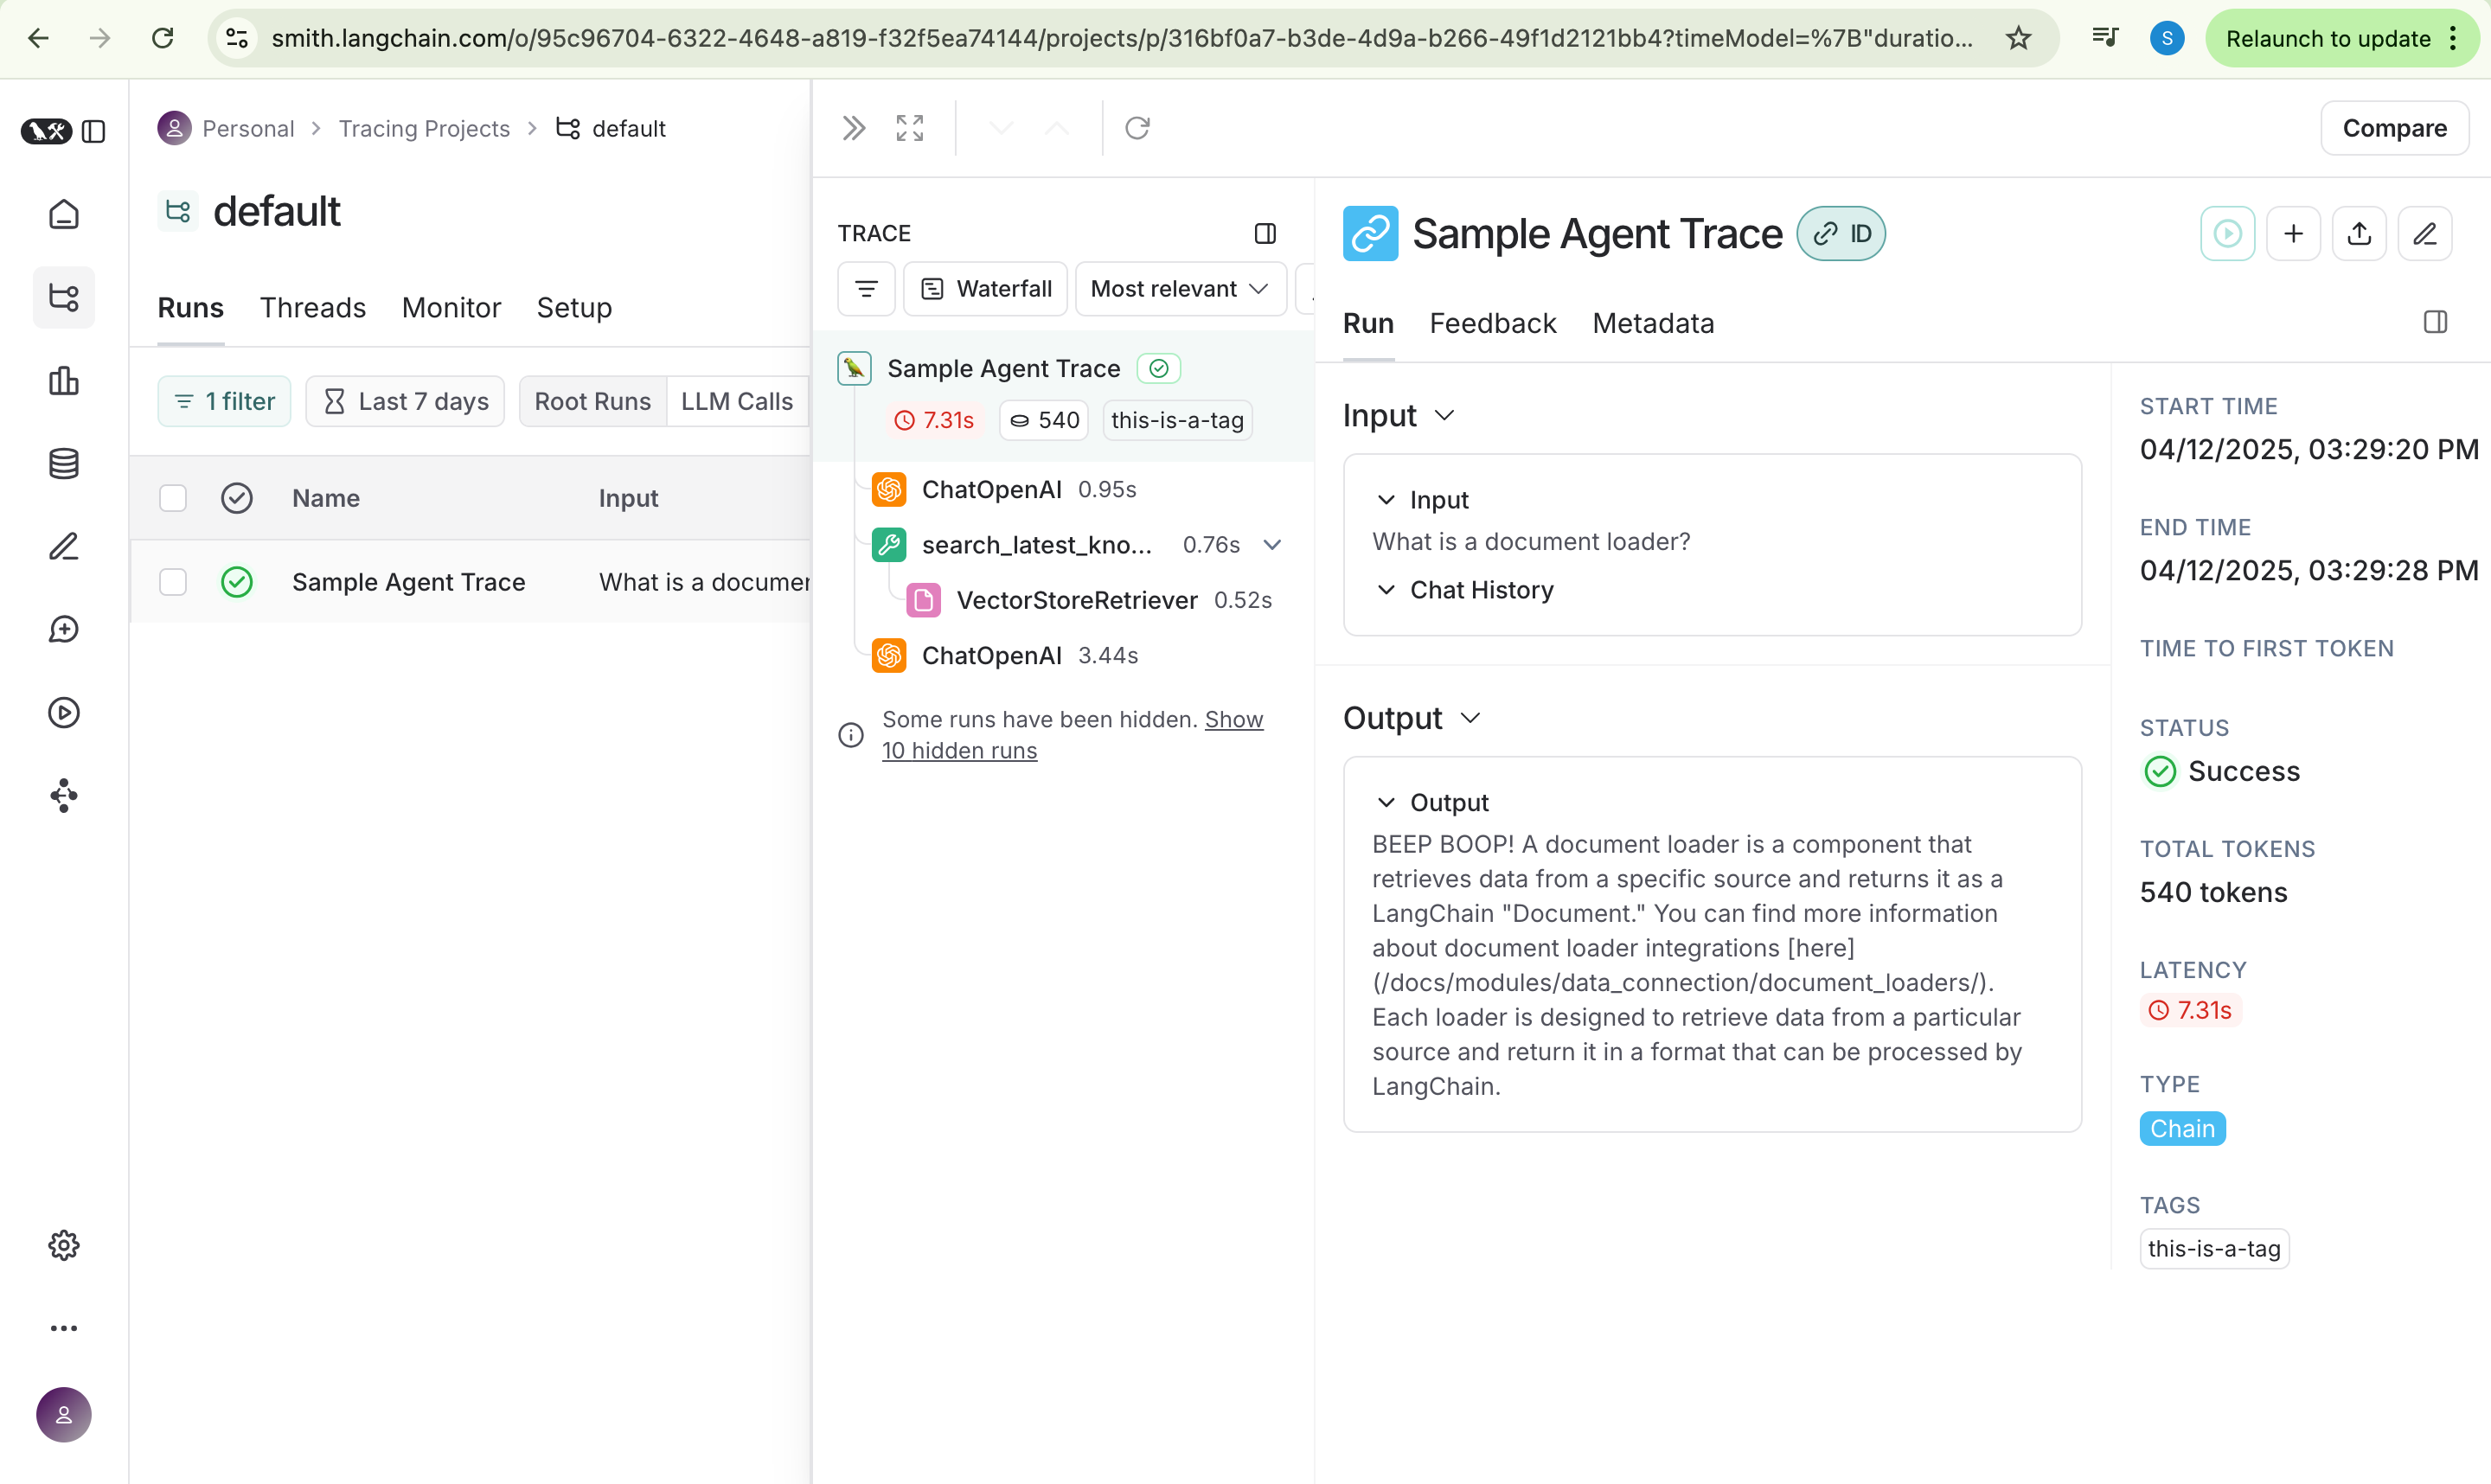

In [ ]:
#  Trace
Image("/content/Screenshot 2025-04-11 at 11.35.54 PM.png")